In [1]:
#1

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score,LeaveOneOut
from sklearn import metrics
from sklearn import preprocessing
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV
import warnings
warnings.filterwarnings("ignore")

In [3]:
data = pd.read_csv('F:/Dataset/Bank_Personal_Loan_Modelling(1).csv') 
data 

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1/60,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1/50,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1/00,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2/70,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1/00,2,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,29,3,40,92697,1,1/90,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0/40,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0/30,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0/50,2,0,0,0,0,1,0


In [4]:
df=pd.DataFrame(data)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   ID                  5000 non-null   int64 
 1   Age                 5000 non-null   int64 
 2   Experience          5000 non-null   int64 
 3   Income              5000 non-null   int64 
 4   ZIP Code            5000 non-null   int64 
 5   Family              5000 non-null   int64 
 6   CCAvg               5000 non-null   object
 7   Education           5000 non-null   int64 
 8   Mortgage            5000 non-null   int64 
 9   Personal Loan       5000 non-null   int64 
 10  Securities Account  5000 non-null   int64 
 11  CD Account          5000 non-null   int64 
 12  Online              5000 non-null   int64 
 13  CreditCard          5000 non-null   int64 
dtypes: int64(13), object(1)
memory usage: 547.0+ KB


In [6]:
df1=pd.DataFrame(df)

In [7]:
df1['CCAvg'] = df1['CCAvg'].apply(lambda x: x.replace('/', '.')).astype(float)

In [8]:
df1['Experience'] = df1['Experience'].abs()

In [9]:
df.describe()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2500.500000,45.338400,20.134600,73.774200,93152.503000,2.396400,1.937938,1.881000,56.498800,0.096000,0.104400,0.06040,0.596800,0.294000
std,1443.520003,11.463166,11.415189,46.033729,2121.852197,1.147663,1.747659,0.839869,101.713802,0.294621,0.305809,0.23825,0.490589,0.455637
min,1.000000,23.000000,0.000000,8.000000,9307.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,1250.750000,35.000000,10.000000,39.000000,91911.000000,1.000000,0.700000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,2500.500000,45.000000,20.000000,64.000000,93437.000000,2.000000,1.500000,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,3750.250000,55.000000,30.000000,98.000000,94608.000000,3.000000,2.500000,3.000000,101.000000,0.000000,0.000000,0.00000,1.000000,1.000000
max,5000.000000,67.000000,43.000000,224.000000,96651.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.000000,1.00000,1.000000,1.000000


In [10]:
print("show missing value :",df.isnull().sum()) 

show missing value : ID                    0
Age                   0
Experience            0
Income                0
ZIP Code              0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal Loan         0
Securities Account    0
CD Account            0
Online                0
CreditCard            0
dtype: int64


In [11]:
df1.drop(columns="ID",inplace=True)
df1

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,35,8,45,91330,4,1.0,2,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,65,40,49,90034,3,0.5,2,0,0,0,0,1,0


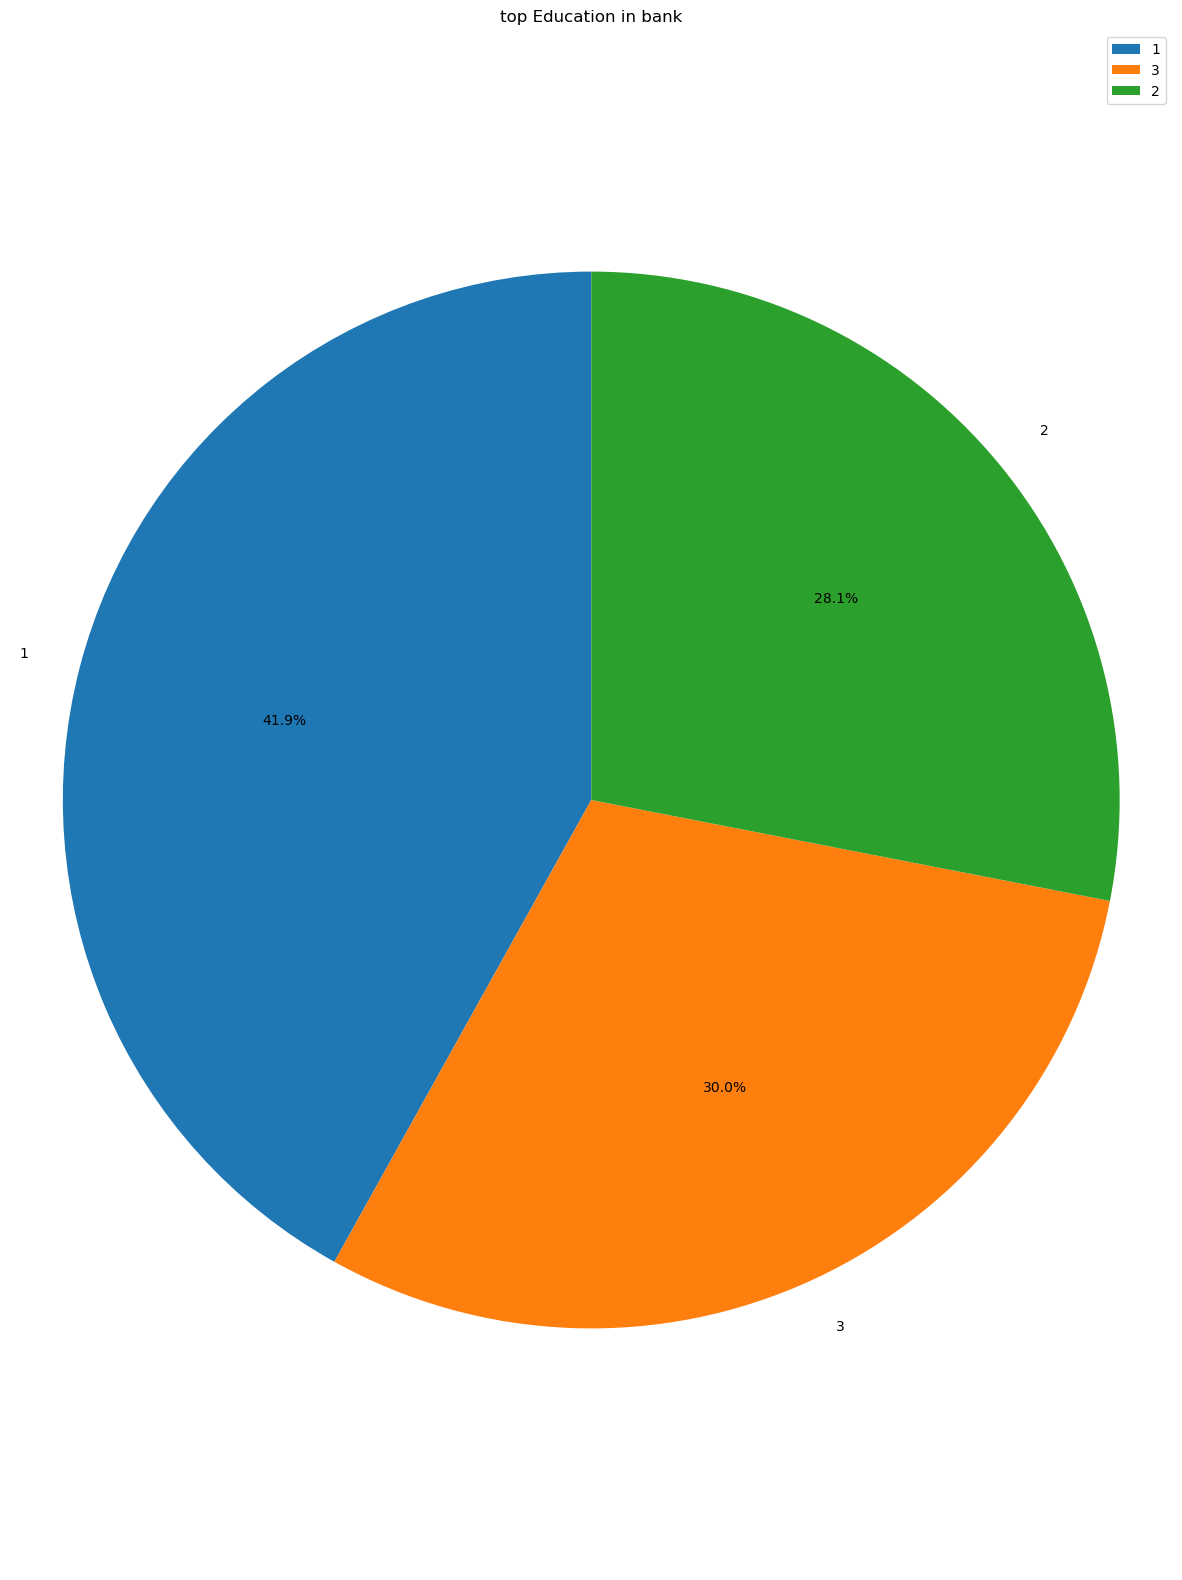

In [12]:

fig1,ax=plt.subplots(figsize=(15,20))  
labels=list(df1 ["Education"].value_counts().index)
sizes=list(df1 ["Education"].value_counts().values)
ax.set_title("top Education in bank") 

ax.pie(sizes,labels=labels,autopct="%1.1f%%",shadow=False,startangle=90)  
ax.axis("equal")
plt.legend(loc="best") 
plt.show() 

<Axes: xlabel='Personal Loan', ylabel='Age'>

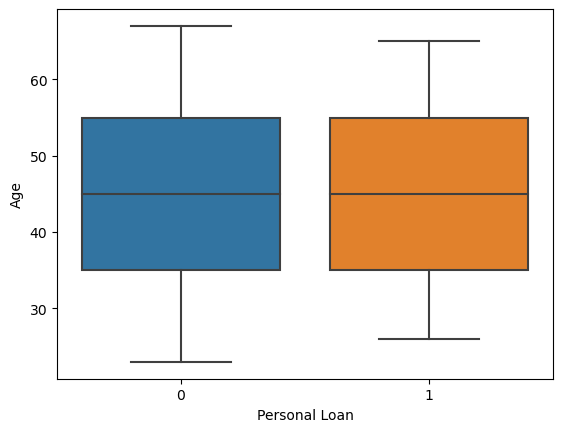

In [13]:
sns.boxplot(data=df, x="Personal Loan", y="Age")

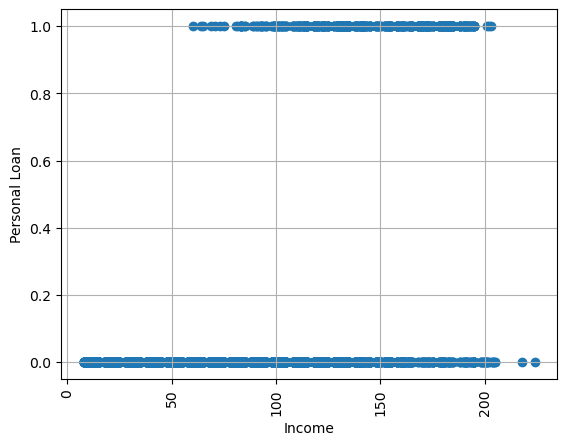

In [14]:
plt.xticks(rotation=90)  
plt.xlabel("Income",fontsize=10) 
plt.ylabel("Personal Loan",fontsize=10)
plt.grid()
plt.scatter(df["Income"],df["Personal Loan"])

<Axes: xlabel='Experience', ylabel='count'>

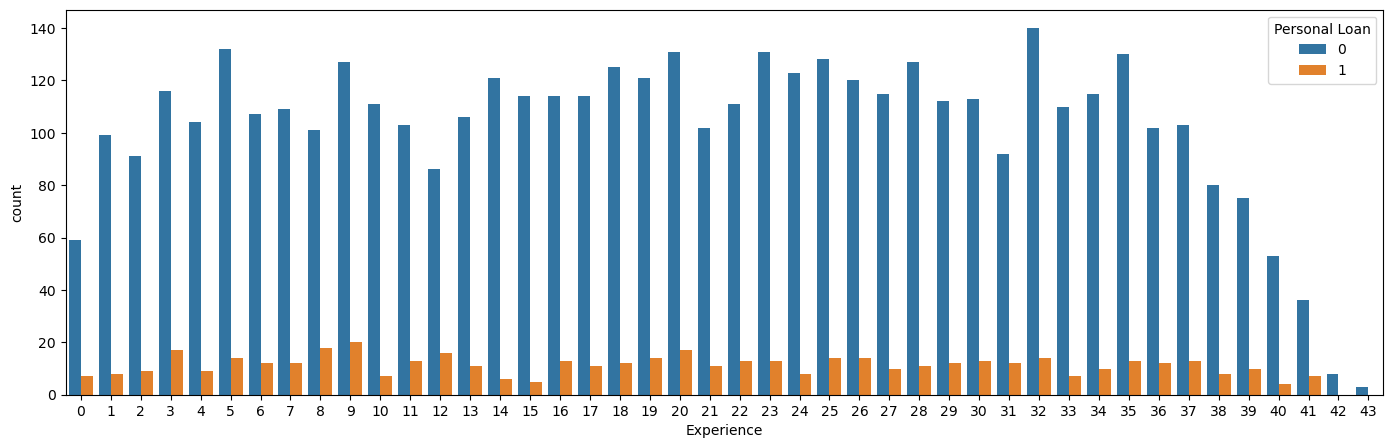

In [15]:
plt.figure(figsize=[17,5])
sns.countplot(data=df1, x="Experience", hue="Personal Loan")

<Axes: xlabel='CCAvg', ylabel='count'>

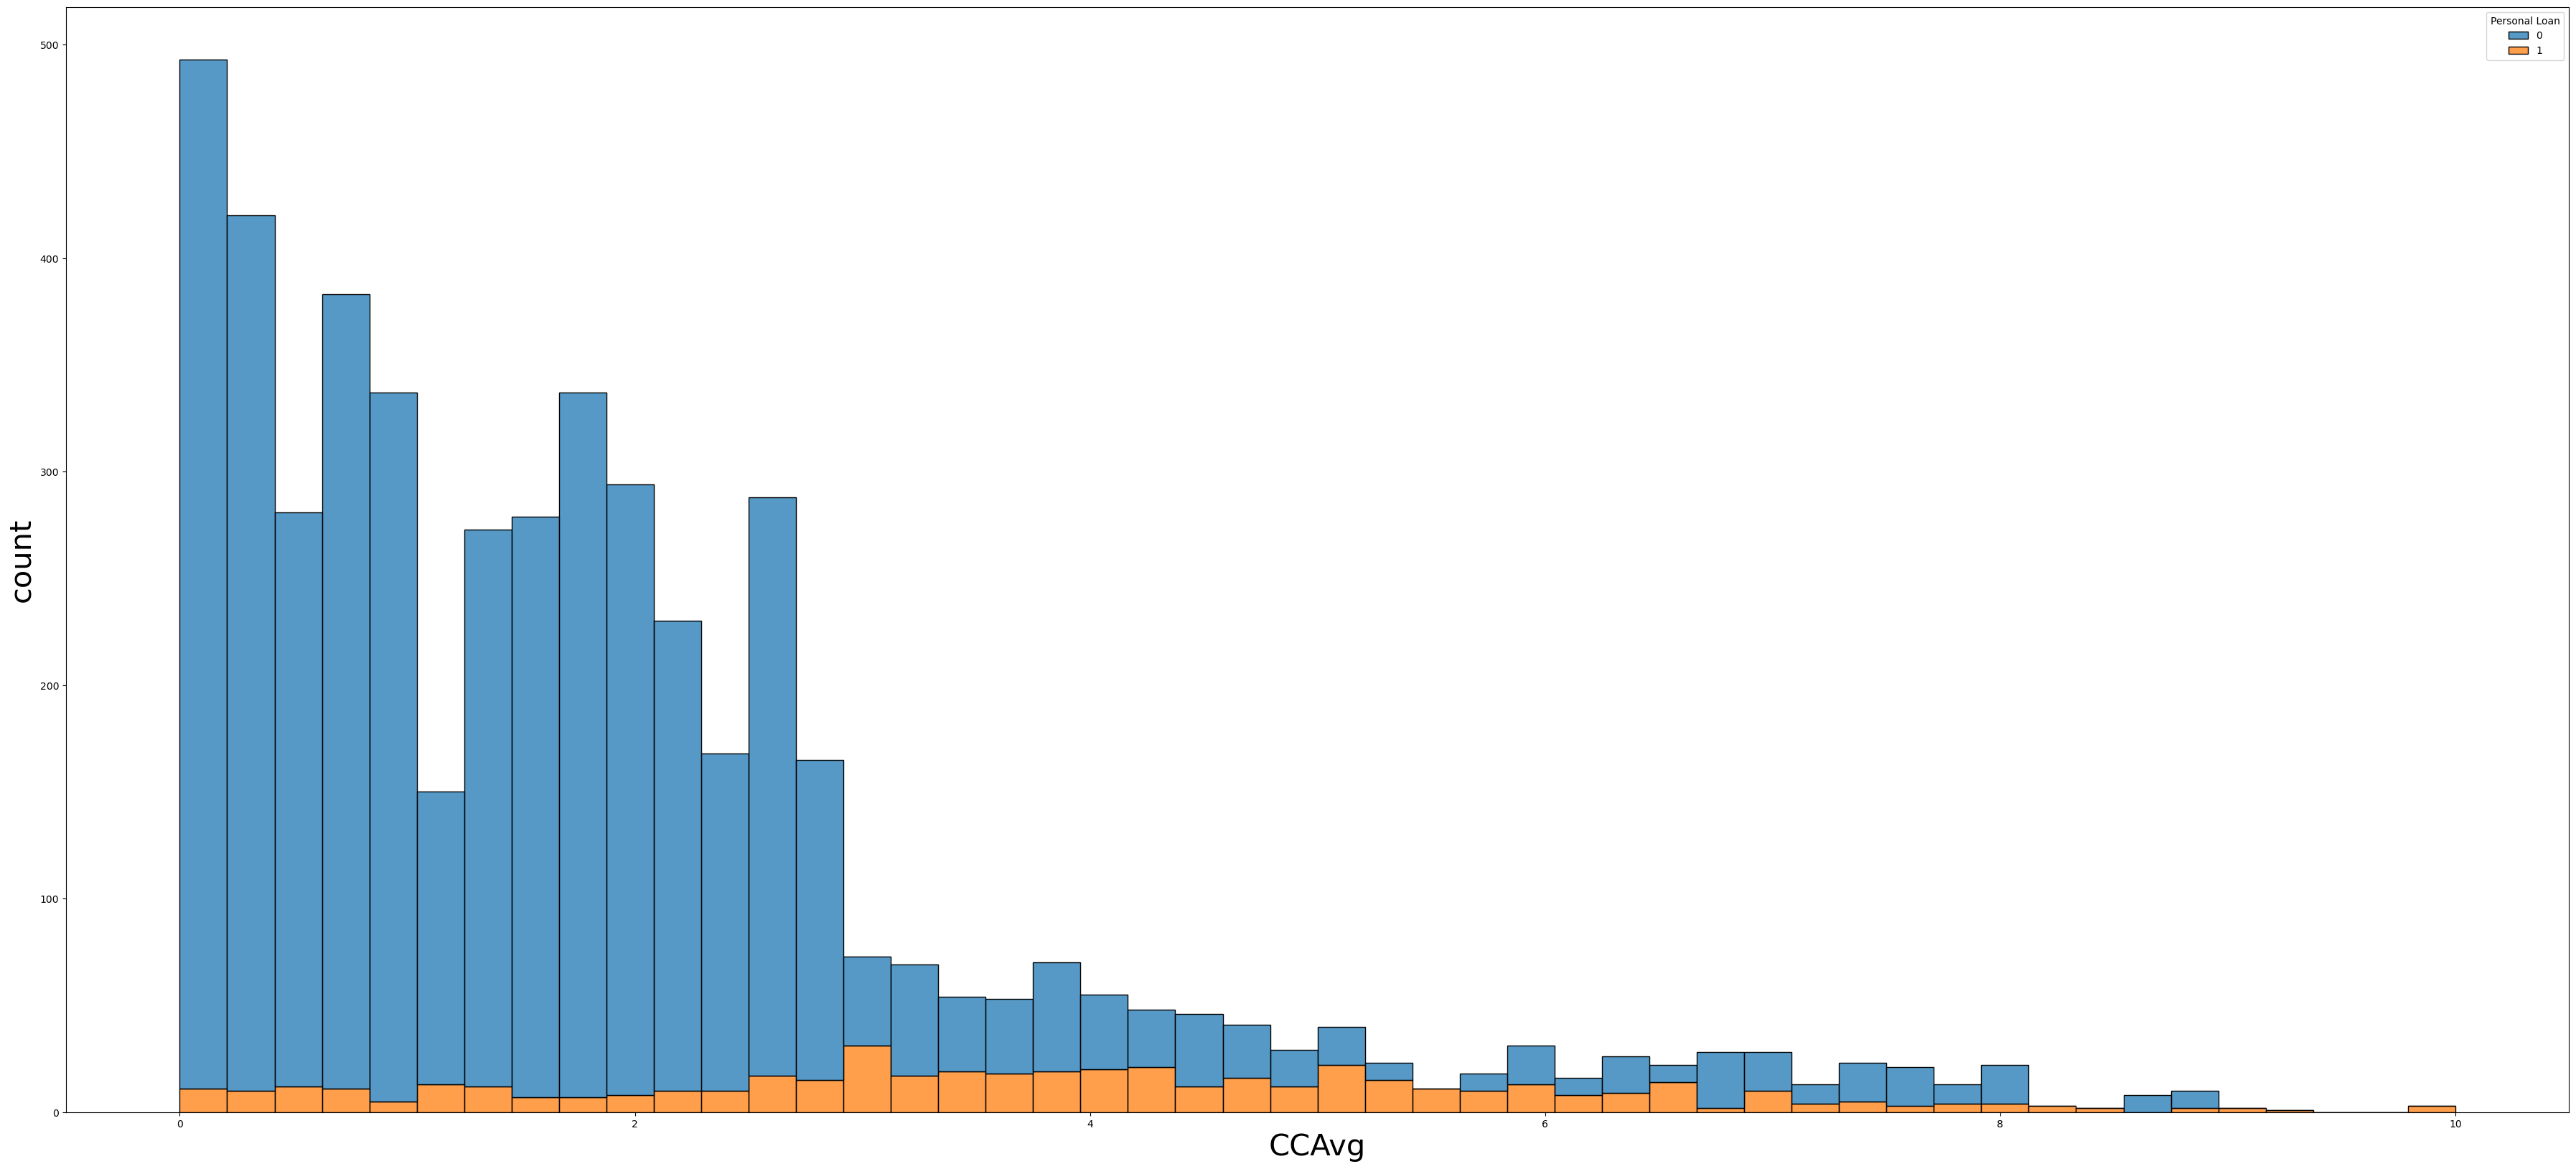

In [16]:
plt.figure(figsize=[45,20])
plt.xlabel("CCAvg",fontsize=30) 
plt.ylabel("count",fontsize=30)
sns.histplot(data=df1, x="CCAvg", hue="Personal Loan",multiple="stack")

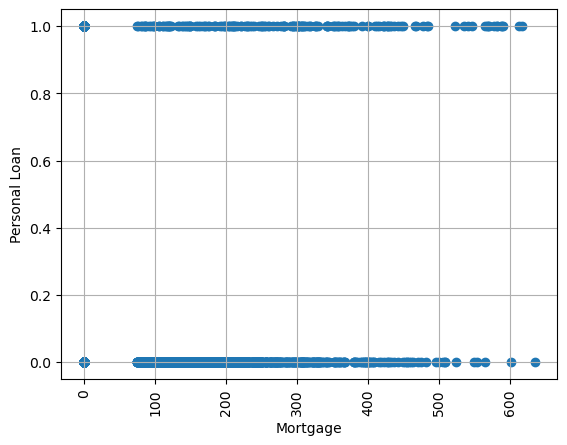

In [17]:
plt.xticks(rotation=90)
plt.xlabel("Mortgage",fontsize=10) 
plt.ylabel("Personal Loan",fontsize=10)
plt.scatter(df["Mortgage"],df["Personal Loan"])  
plt.grid()

<Axes: >

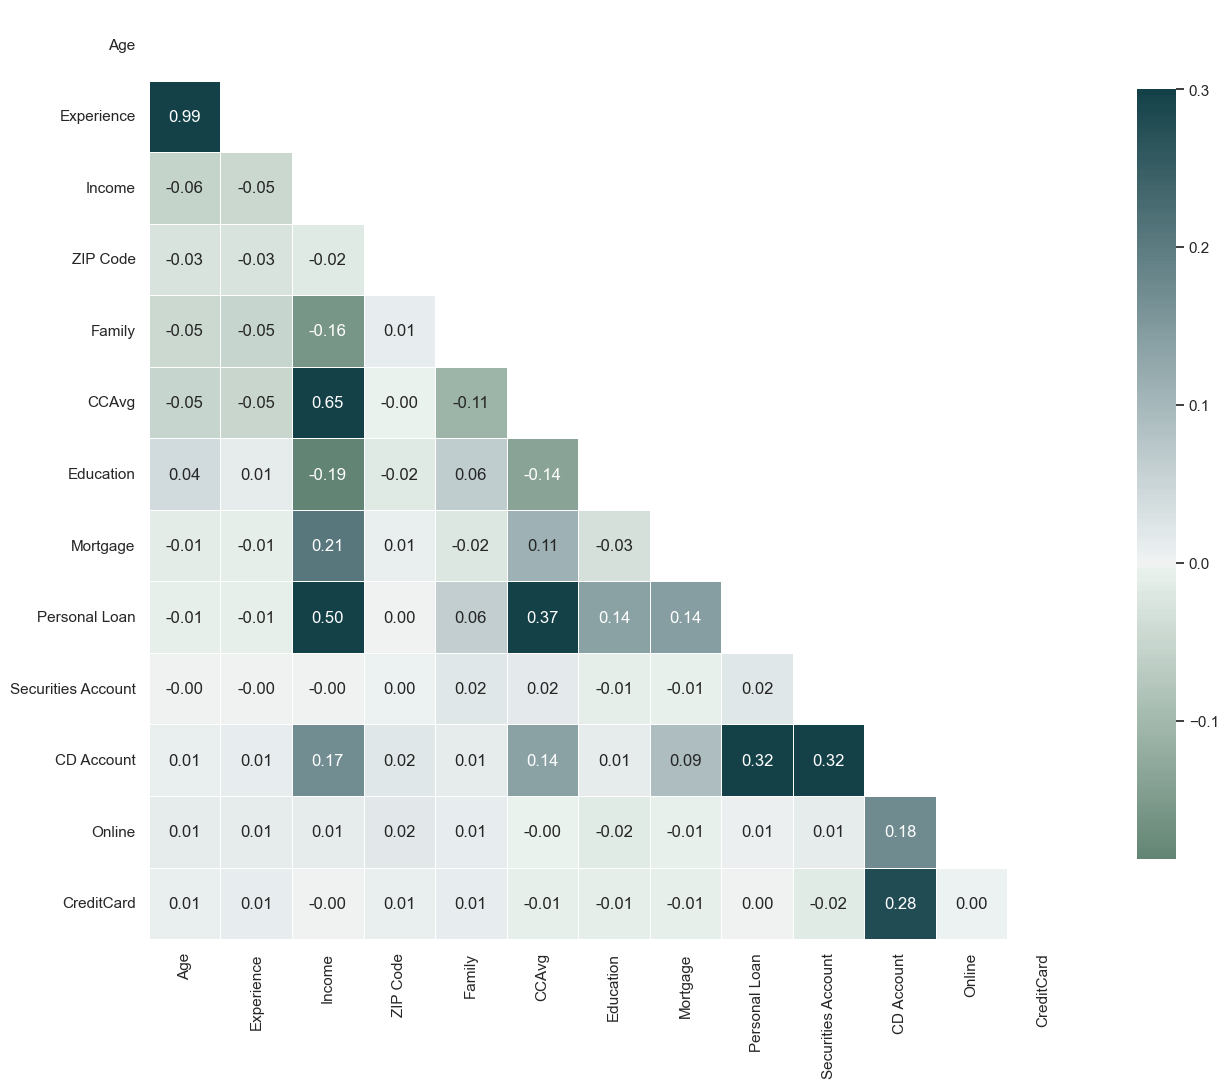

In [18]:
sns.set_theme(style="white") 
corr=df1.corr()
mask=np.triu(np.ones_like(corr,dtype=bool))
f,ax=plt.subplots(figsize=(15,20)) 
cmap=sns.diverging_palette(145,210,s=85,l=25,n=7,center="light",as_cmap=True)
sns.heatmap(corr,annot=True,fmt=".2f",mask=mask,cmap=cmap,vmax=.3,center=0,square=True,linewidths=.5,cbar_kws={"shrink":.5})

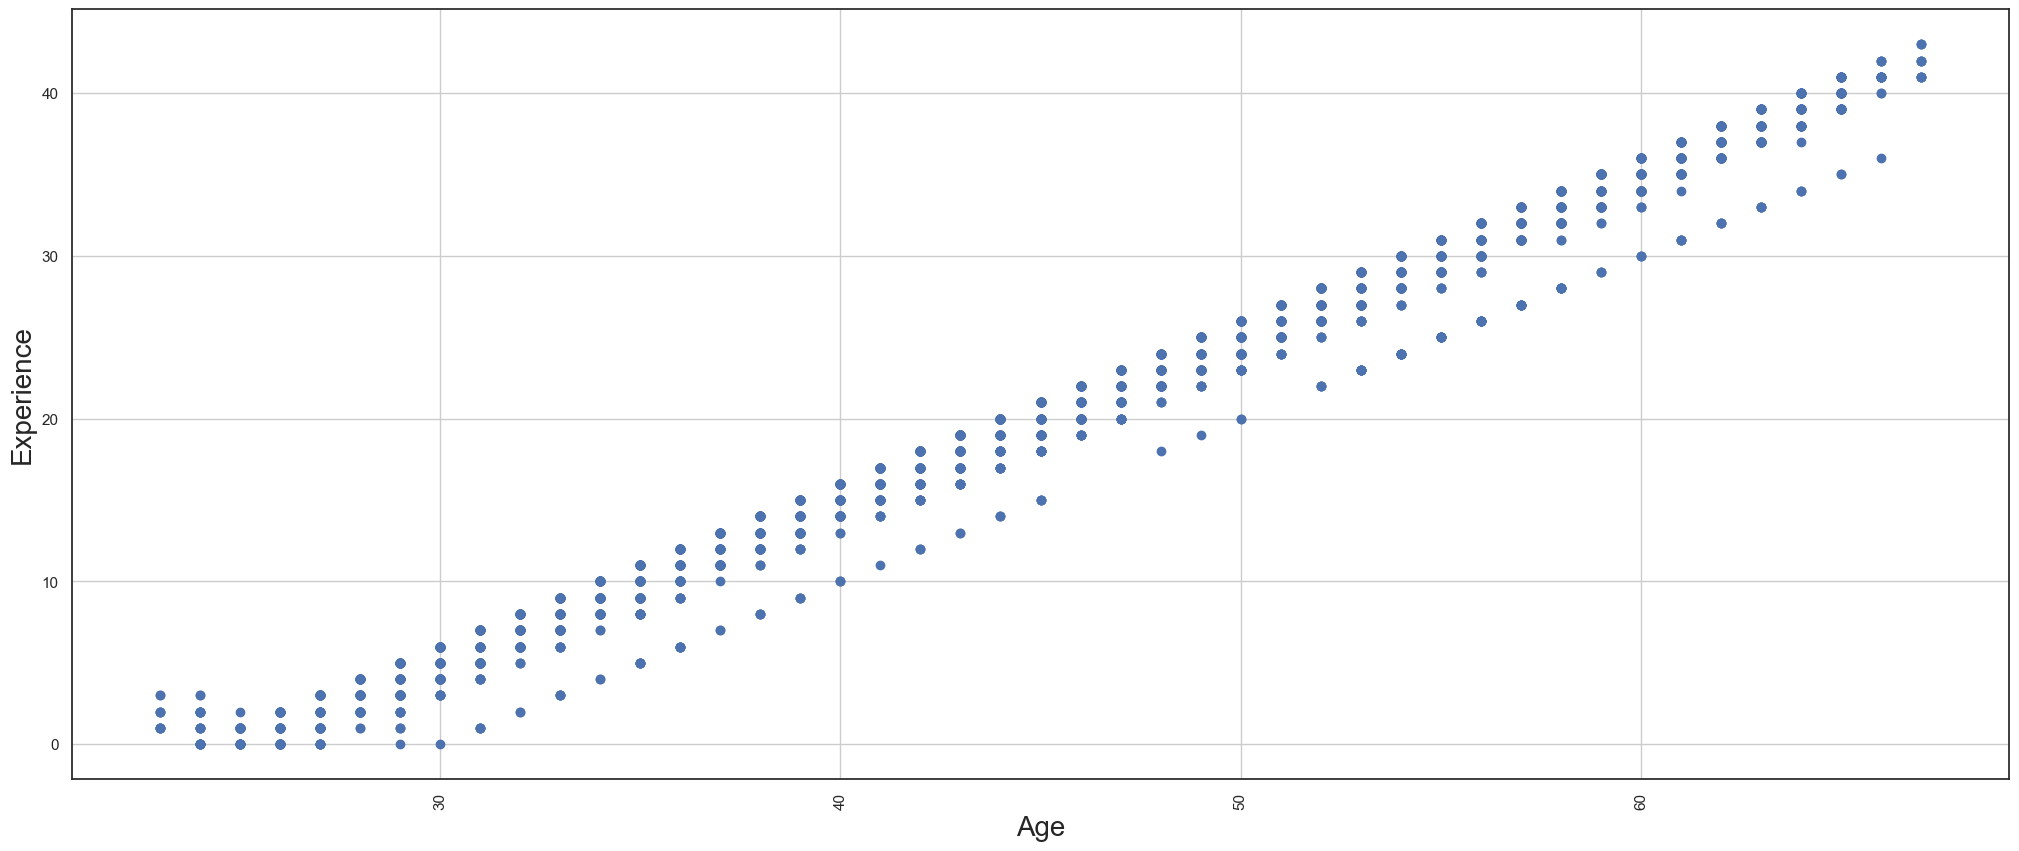

In [19]:
fig , ax = plt.subplots(figsize=(25,10))
plt.xticks(rotation=90) 
plt.xlabel("Age",fontsize=20) 
plt.ylabel("Experience",fontsize=20) 
plt.grid() 
ax=plt.scatter(df1["Age"],df1["Experience"])

<Axes: xlabel='CD Account', ylabel='CreditCard'>

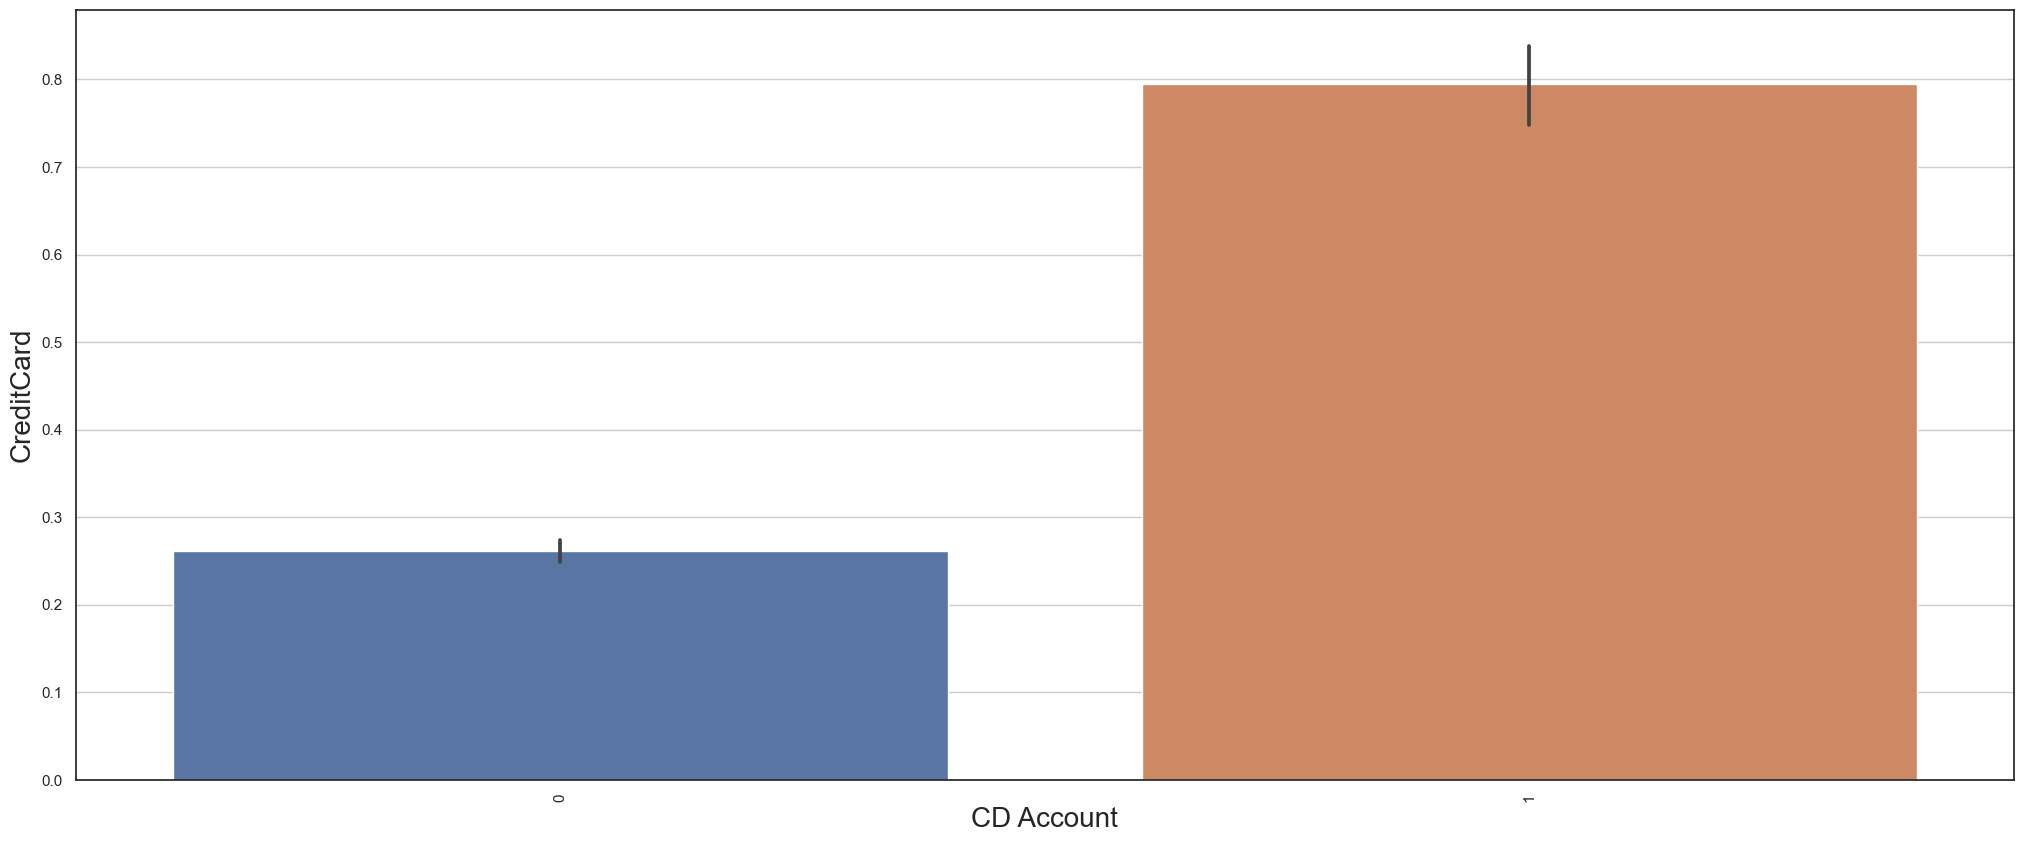

In [20]:
fig , ax = plt.subplots(figsize=(25,10))
plt.xticks(rotation=90) 
plt.xlabel("CD Account",fontsize=20) 
plt.ylabel("CreditCard",fontsize=20) 
plt.grid() 
sns.barplot(data=df, x="CD Account", y="CreditCard")

In [21]:
print("show nane :",df.isna().sum()) 

show nane : ID                    0
Age                   0
Experience            0
Income                0
ZIP Code              0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal Loan         0
Securities Account    0
CD Account            0
Online                0
CreditCard            0
dtype: int64


In [22]:
Income2=df1["Income"]**2
CCAvg2=df1["CCAvg"]**2
Mortgage2=df1["Mortgage"]**2
Education2=df1["Education"]**2

In [23]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 5000 non-null   int64  
 1   Experience          5000 non-null   int64  
 2   Income              5000 non-null   int64  
 3   ZIP Code            5000 non-null   int64  
 4   Family              5000 non-null   int64  
 5   CCAvg               5000 non-null   float64
 6   Education           5000 non-null   int64  
 7   Mortgage            5000 non-null   int64  
 8   Personal Loan       5000 non-null   int64  
 9   Securities Account  5000 non-null   int64  
 10  CD Account          5000 non-null   int64  
 11  Online              5000 non-null   int64  
 12  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(12)
memory usage: 507.9 KB


In [24]:
df1.insert(13,"Income2",Income2)
df1.insert(14,"CCAvg2",CCAvg2)
df1.insert(15,"Mortgage2",Mortgage2)
df1.insert(16,"Education2",Education2)

In [25]:
df1["inco_cd"]=df1["CD Account"]*df1["Income"]
df1["inco_mort"]=df1["Mortgage"]*df1["Income"]
df1["incom_ccav"]=df1["Income"]*df1["CCAvg"]
df1["incom_edu"]=df1["Education"]*df1["Income"]
df1["incom_famil"]=df1["Income"]*df1["Family"]

In [26]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 5000 non-null   int64  
 1   Experience          5000 non-null   int64  
 2   Income              5000 non-null   int64  
 3   ZIP Code            5000 non-null   int64  
 4   Family              5000 non-null   int64  
 5   CCAvg               5000 non-null   float64
 6   Education           5000 non-null   int64  
 7   Mortgage            5000 non-null   int64  
 8   Personal Loan       5000 non-null   int64  
 9   Securities Account  5000 non-null   int64  
 10  CD Account          5000 non-null   int64  
 11  Online              5000 non-null   int64  
 12  CreditCard          5000 non-null   int64  
 13  Income2             5000 non-null   int64  
 14  CCAvg2              5000 non-null   float64
 15  Mortgage2           5000 non-null   int64  
 16  Educat

In [27]:
scaler = preprocessing.MinMaxScaler(feature_range=(0,1))
norm = scaler.fit_transform(df1.iloc[:,[2,3,4,5,6,7,9,10,11,12,13,14,15,16,17,18,19,20,21]])
norm_df1 = pd.DataFrame(norm,columns = ["Income","ZIP Code","Family","CCAvg","Education","Mortgage","Securities Account",
                                        "CD Account","Online","CreditCard","Income2","CCAvg2","Mortgage2","Education2","inco_cd",
                                        "inco_mort","incom_ccav","incom_edu","incom_famil"])
norm_df1["Personal Loan"] = df1["Personal Loan"]
norm_df1.head(5)

,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Securities Account,CD Account,Online,CreditCard,Income2,CCAvg2,Mortgage2,Education2,inco_cd,inco_mort,incom_ccav,incom_edu,incom_famil,Personal Loan
0,0.189815,0.936527,1.000000,0.16,0.0,0.0,1.0,0.0,0.0,0.0,0.046636,0.0256,0.0,0.000,0.0,0.0,0.038621,0.068220,0.243523,0
1,0.120370,0.924872,0.666667,0.15,0.0,0.0,1.0,0.0,0.0,0.0,0.021791,0.0225,0.0,0.000,0.0,0.0,0.025123,0.043261,0.121762,0
2,0.013889,0.977892,0.000000,0.10,0.0,0.0,0.0,0.0,0.0,0.0,0.001137,0.0100,0.0,0.000,0.0,0.0,0.005419,0.004992,0.003886,0
3,0.425926,0.970931,0.000000,0.27,0.5,0.0,0.0,0.0,0.0,0.0,0.198276,0.0729,0.0,0.375,0.0,0.0,0.133005,0.319468,0.119171,0
4,0.171296,0.939080,1.000000,0.10,0.5,0.0,0.0,0.0,0.0,1.0,0.039132,0.0100,0.0,0.375,0.0,0.0,0.022167,0.136439,0.222798,0


In [28]:
norm_df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Income              5000 non-null   float64
 1   ZIP Code            5000 non-null   float64
 2   Family              5000 non-null   float64
 3   CCAvg               5000 non-null   float64
 4   Education           5000 non-null   float64
 5   Mortgage            5000 non-null   float64
 6   Securities Account  5000 non-null   float64
 7   CD Account          5000 non-null   float64
 8   Online              5000 non-null   float64
 9   CreditCard          5000 non-null   float64
 10  Income2             5000 non-null   float64
 11  CCAvg2              5000 non-null   float64
 12  Mortgage2           5000 non-null   float64
 13  Education2          5000 non-null   float64
 14  inco_cd             5000 non-null   float64
 15  inco_mort           5000 non-null   float64
 16  incom_

In [29]:
x=norm_df1.iloc[:,:19]
y=norm_df1["Personal Loan"].values.reshape(-1,1)
x_train, x_test, y_train, y_test=train_test_split(x,y, test_size=0.3,random_state=0)

In [30]:
k=3
clf=KNeighborsClassifier(n_neighbors=k,weights='distance')
clf.fit(x_train,y_train.ravel())
y_pred=clf.predict(x_test)

In [31]:
print("Accuracy :",metrics.accuracy_score(y_test,y_pred))

Accuracy : 0.9793333333333333


In [32]:
print("Accuracy :",metrics.accuracy_score(y_train,clf.predict(x_train)))

Accuracy : 1.0


In [33]:
k=60
ACC=np.zeros((k))

for i in range(1,k+1):
    clf=KNeighborsClassifier(n_neighbors=i,weights='distance')
    clf.fit(x_train,y_train.ravel())
    y_pred=clf.predict(x_test)
    ACC[i-1]=metrics.accuracy_score(y_test,y_pred)
    
    
ACC

array([0.974     , 0.974     , 0.97933333, 0.98      , 0.97733333,
       0.978     , 0.97666667, 0.97666667, 0.976     , 0.97533333,
       0.97533333, 0.97533333, 0.97266667, 0.974     , 0.974     ,
       0.974     , 0.97533333, 0.97466667, 0.97333333, 0.96933333,
       0.96933333, 0.968     , 0.968     , 0.96733333, 0.96866667,
       0.96533333, 0.96533333, 0.96466667, 0.96333333, 0.96333333,
       0.962     , 0.962     , 0.962     , 0.962     , 0.96066667,
       0.96133333, 0.96133333, 0.96133333, 0.96133333, 0.96133333,
       0.96066667, 0.96066667, 0.96      , 0.95933333, 0.95933333,
       0.95866667, 0.95933333, 0.958     , 0.95733333, 0.95666667,
       0.95666667, 0.95666667, 0.956     , 0.956     , 0.95533333,
       0.956     , 0.95533333, 0.956     , 0.956     , 0.95666667])

In [34]:
print(np.max(ACC))
print(np.min(ACC))

0.98
0.9553333333333334


In [35]:
print(classification_report(y,clf.predict(x)))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      4520
           1       1.00      0.86      0.93       480

    accuracy                           0.99      5000
   macro avg       0.99      0.93      0.96      5000
weighted avg       0.99      0.99      0.99      5000



In [36]:
### k=3

In [37]:
import matplotlib.pyplot as plt

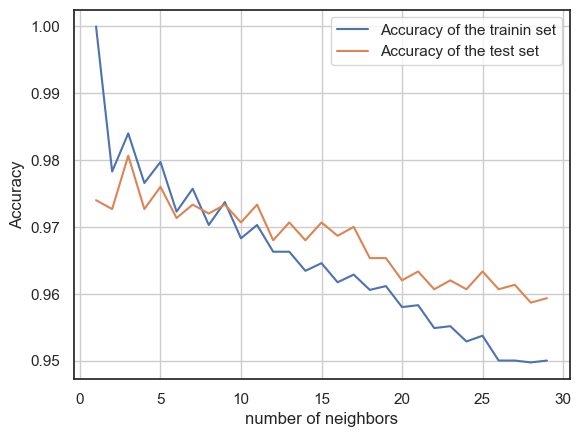

In [38]:
training_acc=[]
test_acc =[]

neighbors_setting=range(1,30)

for n_neighbors in neighbors_setting:
    clf=KNeighborsClassifier(n_neighbors=n_neighbors)
    clf.fit(x_train,y_train.ravel())
    training_acc.append(clf.score(x_train,y_train.ravel()))
    test_acc.append(clf.score(x_test,y_test))
    
                    
plt.plot(neighbors_setting,training_acc,label="Accuracy of the trainin set")    
plt.plot(neighbors_setting,test_acc,label="Accuracy of the test set")
plt.ylabel("Accuracy")  
plt.xlabel("number of neighbors")
plt.grid()
plt.legend()                    

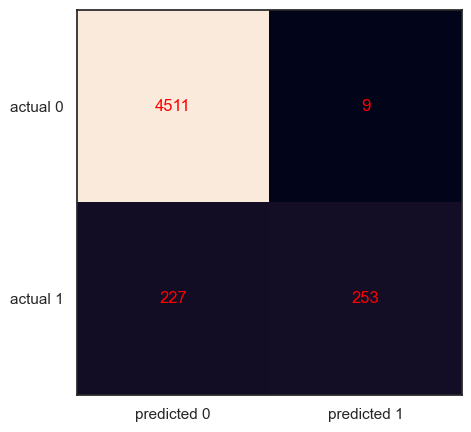

In [39]:
cm=confusion_matrix(y,clf.predict(x))

fig,ax=plt.subplots(figsize=(5,5))
ax.imshow(cm)
ax.xaxis.set(ticks=(0,1),ticklabels=("predicted 0","predicted 1"))
ax.yaxis.set(ticks=(0,1),ticklabels=("actual 0","actual 1"))
ax.set_ylim(1.5,-0.5)
for i in range(2):
    for j in range(2):
        ax.text(j,i,cm[i,j],ha="center",va="center",color="red")
    
plt.show()

In [40]:
TP=cm[0,0]
TN=cm[1,1]
FP=cm[0,1]
FN=cm[1,0]

In [41]:
classification_error=(FP+FN)/float(TP+TN+FP+FN)
print("classification_error :{0:0.4f}".format(classification_error))

classification_error :0.0472


In [42]:
p1={"Income":30,"ZIP Code":92037,"Family":3,"CCAvg":1.2 ,"Education":3 ,"Mortgage":0,"Personal Loan":0 ,"Securities Account":1,"CD Account": 0 ,"Online":1,"CreditCard":1}
df_test = pd.DataFrame([p1])

   
df_test["Income2"]=df_test["Income"]**2             
df_test["CCAvg2"]=df_test["CCAvg"]**2              
df_test["Mortgage2"]=df_test["Mortgage"]**2          
df_test["Education2"]= df_test["Education"]**2  
df_test["inco_cd"]=df_test["Income"]*df_test["CD Account"]
df_test["inco_mort"]=df_test["Income"]*df_test["Mortgage"] 
df_test["incom_ccav"]=df_test["Income"]*df_test["CCAvg"]       
df_test["incom_edu"]= df_test["Income"]*df_test["Education"]                    
df_test["incom_famil"]=df_test["Income"]*df_test["Family"] 

In [43]:
df1.drop(columns="Age",inplace=True)
df1.drop(columns="Experience",inplace=True)

In [44]:
df2 = df1.append([df_test],ignore_index=True)
df2

,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard,Income2,CCAvg2,Mortgage2,Education2,inco_cd,inco_mort,incom_ccav,incom_edu,incom_famil
0,49,91107,4,1.6,1,0,0,1,0,0,0,2401,2.56,0,1,0,0,78.4,49,196
1,34,90089,3,1.5,1,0,0,1,0,0,0,1156,2.25,0,1,0,0,51.0,34,102
2,11,94720,1,1.0,1,0,0,0,0,0,0,121,1.00,0,1,0,0,11.0,11,11
3,100,94112,1,2.7,2,0,0,0,0,0,0,10000,7.29,0,4,0,0,270.0,200,100
4,45,91330,4,1.0,2,0,0,0,0,0,1,2025,1.00,0,4,0,0,45.0,90,180
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4996,15,92037,4,0.4,1,85,0,0,0,1,0,225,0.16,7225,1,0,1275,6.0,15,60
4997,24,93023,2,0.3,3,0,0,0,0,0,0,576,0.09,0,9,0,0,7.2,72,48
4998,49,90034,3,0.5,2,0,0,0,0,1,0,2401,0.25,0,4,0,0,24.5,98,147
4999,83,92612,3,0.8,1,0,0,0,0,1,1,6889,0.64,0,1,0,0,66.4,83,249


In [45]:
print("show missing value :",df2.isnull().sum())

show missing value : Income                0
ZIP Code              0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal Loan         0
Securities Account    0
CD Account            0
Online                0
CreditCard            0
Income2               0
CCAvg2                0
Mortgage2             0
Education2            0
inco_cd               0
inco_mort             0
incom_ccav            0
incom_edu             0
incom_famil           0
dtype: int64


In [46]:
scaler = preprocessing.MinMaxScaler(feature_range=(0,1))
Nt = scaler.fit_transform(df2.iloc[:,[0,1,2,3,4,5,7,8,9,10,11,12,13,14,15,16,17,18,19]])
df_test1 = pd.DataFrame(Nt,columns = ["Income","ZIP Code","Family","CCAvg","Education" ,"Mortgage" ,"Securities Account","CD Account","Online","CreditCard",
                                      "Income2","CCAvg2","Mortgage2","Education2","inco_cd","inco_mort","incom_ccav","incom_edu" ,"incom_famil"])
df_test1["Personal Loan"]=df2["Personal Loan"]
df_test1.head(5)

,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Securities Account,CD Account,Online,CreditCard,Income2,CCAvg2,Mortgage2,Education2,inco_cd,inco_mort,incom_ccav,incom_edu,incom_famil,Personal Loan
0,0.189815,0.936527,1.000000,0.16,0.0,0.0,1.0,0.0,0.0,0.0,0.046636,0.0256,0.0,0.000,0.0,0.0,0.038621,0.068220,0.243523,0
1,0.120370,0.924872,0.666667,0.15,0.0,0.0,1.0,0.0,0.0,0.0,0.021791,0.0225,0.0,0.000,0.0,0.0,0.025123,0.043261,0.121762,0
2,0.013889,0.977892,0.000000,0.10,0.0,0.0,0.0,0.0,0.0,0.0,0.001137,0.0100,0.0,0.000,0.0,0.0,0.005419,0.004992,0.003886,0
3,0.425926,0.970931,0.000000,0.27,0.5,0.0,0.0,0.0,0.0,0.0,0.198276,0.0729,0.0,0.375,0.0,0.0,0.133005,0.319468,0.119171,0
4,0.171296,0.939080,1.000000,0.10,0.5,0.0,0.0,0.0,0.0,1.0,0.039132,0.0100,0.0,0.375,0.0,0.0,0.022167,0.136439,0.222798,0


In [47]:
x=df2.drop(["Personal Loan"],axis=1)[:5000]
y=df2[["Personal Loan"]][:5000].values.reshape(-1,1)
x_finall=df2.drop(["Personal Loan"],axis=1)[5000:]

In [48]:
clf.fit(x,y)
y_pred=clf.predict(x_finall)

In [49]:
y_pred

array([0], dtype=int64)

SVM

In [50]:
clf2=SVC(C=0.1,kernel="linear",gamma="scale",random_state=24)
clf2.fit(x_train,y_train.ravel())
y_pred=clf2.predict(x_test)

In [51]:
print("Accuracy :",metrics.accuracy_score(y_test,y_pred))

Accuracy : 0.962


In [52]:
print("Accuracy :",metrics.accuracy_score(y_train,clf.predict(x_train)))

Accuracy : 0.8994285714285715


In [53]:
print(classification_report(y,clf2.predict(x)))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00      4520
           1       0.10      1.00      0.18       480

    accuracy                           0.10      5000
   macro avg       0.05      0.50      0.09      5000
weighted avg       0.01      0.10      0.02      5000



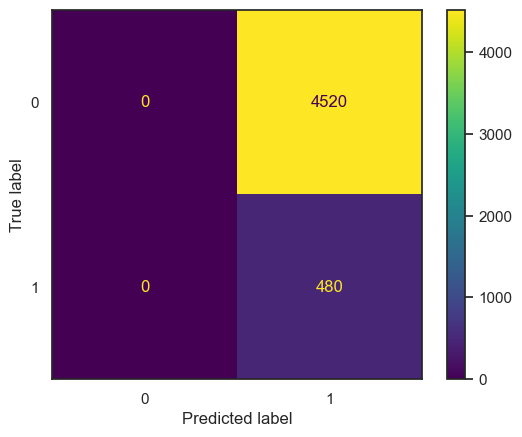

In [54]:
actual=y
predicted=clf2.predict(x)

confiusion_matrix=metrics.confusion_matrix(actual,predicted)
cm_display=metrics.ConfusionMatrixDisplay(confusion_matrix=confiusion_matrix)

cm_display.plot()
plt.show()

In [55]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Income              5000 non-null   int64  
 1   ZIP Code            5000 non-null   int64  
 2   Family              5000 non-null   int64  
 3   CCAvg               5000 non-null   float64
 4   Education           5000 non-null   int64  
 5   Mortgage            5000 non-null   int64  
 6   Personal Loan       5000 non-null   int64  
 7   Securities Account  5000 non-null   int64  
 8   CD Account          5000 non-null   int64  
 9   Online              5000 non-null   int64  
 10  CreditCard          5000 non-null   int64  
 11  Income2             5000 non-null   int64  
 12  CCAvg2              5000 non-null   float64
 13  Mortgage2           5000 non-null   int64  
 14  Education2          5000 non-null   int64  
 15  inco_cd             5000 non-null   int64  
 16  inco_m

MLP

In [56]:
clf5 = MLPClassifier(hidden_layer_sizes=(32,12,8),activation='relu',solver='adam', alpha=0.0001, batch_size='auto', learning_rate='constant', max_iter=300,random_state=None)

In [57]:
clf5.fit(x_train,y_train.ravel())
y_pred=clf5.predict(x_test)

In [58]:
print("Accuracy :",metrics.accuracy_score(y_test,y_pred))

Accuracy : 0.98


In [59]:
print("Accuracy :",metrics.accuracy_score(y_train,clf.predict(x_train)))

Accuracy : 0.8994285714285715


In [60]:
print(classification_report(y,clf5.predict(x)))

              precision    recall  f1-score   support

           0       0.90      1.00      0.95      4520
           1       0.00      0.00      0.00       480

    accuracy                           0.90      5000
   macro avg       0.45      0.50      0.47      5000
weighted avg       0.82      0.90      0.86      5000



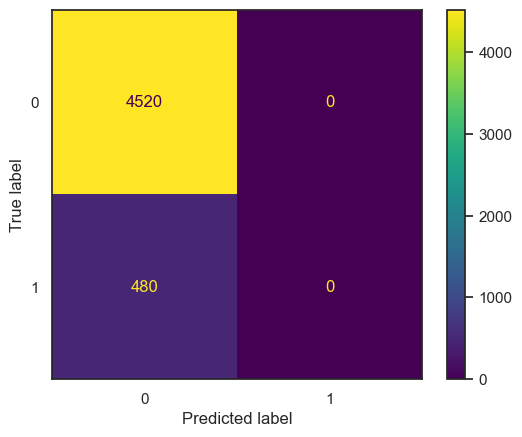

In [61]:
actual=y
predicted=clf5.predict(x)

confiusion_matrix=metrics.confusion_matrix(actual,predicted)
cm_display=metrics.ConfusionMatrixDisplay(confusion_matrix=confiusion_matrix)

cm_display.plot()
plt.show()

k-means

In [62]:
df.drop(columns="Personal Loan",inplace=True)
df.drop(columns="ID",inplace=True)
df.drop(columns="ZIP Code",inplace=True)
df

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Securities Account,CD Account,Online,CreditCard
0,25,1,49,4,1.6,1,0,1,0,0,0
1,45,19,34,3,1.5,1,0,1,0,0,0
2,39,15,11,1,1.0,1,0,0,0,0,0
3,35,9,100,1,2.7,2,0,0,0,0,0
4,35,8,45,4,1.0,2,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...
4995,29,3,40,1,1.9,3,0,0,0,1,0
4996,30,4,15,4,0.4,1,85,0,0,1,0
4997,63,39,24,2,0.3,3,0,0,0,0,0
4998,65,40,49,3,0.5,2,0,0,0,1,0


In [63]:
x=df.loc[:,
        "Age":"CreditCard"]

In [64]:
kmeans=KMeans(n_clusters=3,random_state=0).fit(x)

In [65]:
df["cluster"]=kmeans.labels_

In [68]:
print(kmeans.cluster_centers_)

[[4.53622829e+01 2.01488834e+01 5.83424318e+01 2.47063689e+00
  1.60228288e+00 1.92638544e+00 1.40857734e+02 1.05045492e-01
  5.21091811e-02 5.88089330e-01 2.89495451e-01]
 [4.54025974e+01 2.01948052e+01 7.39468975e+01 2.39278499e+00
  1.95082251e+00 1.88167388e+00 6.55122655e-02 1.05050505e-01
  5.39682540e-02 5.98268398e-01 2.95526696e-01]
 [4.45674847e+01 1.94417178e+01 1.29168712e+02 2.15950920e+00
  3.04579755e+00 1.70552147e+00 3.43466258e+02 9.50920245e-02
  1.59509202e-01 6.13496933e-01 2.94478528e-01]]


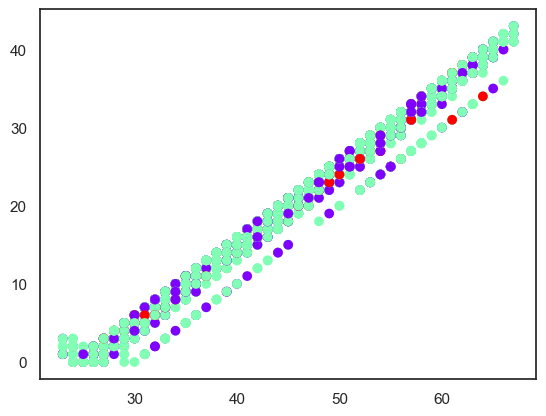

In [69]:
plt.scatter(x.iloc[:,0],x.iloc[:,1],c=df["cluster"],cmap="rainbow")
plt.show()

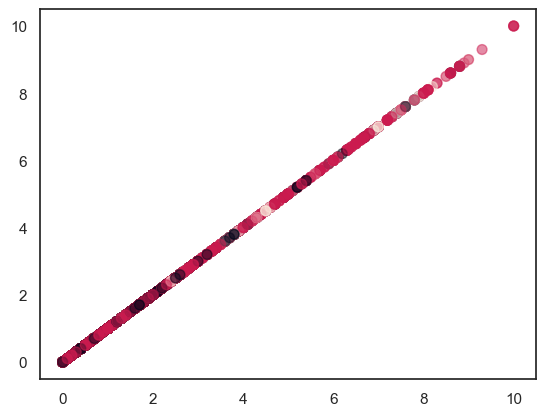

In [71]:
plt.scatter(df["CCAvg"],df["CCAvg"],c=kmeans.labels_.astype(float),s=50,alpha=0.5)
plt.show()